# Regressão — Baseline

Primeiro modelo de referência: split treino/teste, pipeline de pré-processamento e dois
modelos simples (`LinearRegression` e `RandomForestRegressor`) com hiperparâmetros padrão.

Qualquer transformação (padronização, encoding) é **ajustada apenas no treino** e só aplicada
(`transform`) no teste, para evitar vazamento de dados.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42  # fixo em todos os notebooks para o split e os modelos serem comparáveis entre si


## 2. Carregar dados e separar treino/teste

In [2]:
df = pd.read_csv('../data/pib_municipios.csv')

ALVO = 'pib_per_capita'
FEATURES_NUM = ['populacao', 'participacao_agropecuaria', 'participacao_industria',
                'participacao_servicos', 'participacao_administracao_publica']
FEATURES_CAT = ['uf', 'regiao']

X = df[FEATURES_NUM + FEATURES_CAT]
y = df[ALVO]

# split ANTES de qualquer transformação, para evitar vazamento de dados
# test_size=0.2 -> ~1.100 municípios de teste, suficiente para estimativas de erro estáveis
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print('Treino:', X_train.shape, ' Teste:', X_test.shape)


Treino: (4456, 7)  Teste: (1114, 7)


## 3. Pipeline de pré-processamento

In [3]:
# StandardScaler nas numéricas: sem ele, LinearRegression pondera as features pela escala bruta
# (populacao em unidades vs. participacao em %), o que distorce os coeficientes.
# OneHotEncoder(handle_unknown='ignore') evita erro caso uma categoria apareça só no teste.
preprocessador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT),
])


## 4. Modelos baseline

In [4]:
# dois modelos propositalmente bem diferentes: LinearRegression (interpretável, assume relação
# linear) e RandomForest (mais flexível, captura não-linearidades) — a EDA já sugeriu que a relação
# entre features e alvo não é puramente linear (ex.: populacao com correlação ~0)
modelos = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=RANDOM_STATE),
}

resultados = []
pipelines = {}

for nome, estimador in modelos.items():
    pipe = Pipeline([
        ('preprocessador', preprocessador),
        ('modelo', estimador),
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    rmse = mean_squared_error(y_test, pred, squared=False)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    resultados.append({'modelo': nome, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    pipelines[nome] = pipe

    print(f'{nome:18s} | RMSE={rmse:,.2f}  MAE={mae:,.2f}  R2={r2:.3f}')

df_resultados = pd.DataFrame(resultados).set_index('modelo')
df_resultados


C:\Users\edd-j\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


LinearRegression   | RMSE=33,354.67  MAE=14,863.18  R2=0.382


RandomForest       | RMSE=17,253.18  MAE=3,920.57  R2=0.835


C:\Users\edd-j\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,RMSE,MAE,R2
modelo,,,
LinearRegression,33354.672425,14863.175342,0.382428
RandomForest,17253.181666,3920.566991,0.834761


**Resultado:**

| Modelo | RMSE | MAE | R² |
|---|---:|---:|---:|
| LinearRegression | R$ 33.355 | R$ 14.863 | 0,382 |
| RandomForest | R$ 17.253 | R$ 3.921 | 0,835 |

A RandomForest explica mais que o dobro da variância do alvo (R² 0,835 vs. 0,382) e erra, em
mediana, ~4x menos (MAE R$ 3.921 vs. R$ 14.863). Essa diferença enorme confirma a suspeita da EDA:
a relação entre as features e `pib_per_capita` não é linear, e um modelo que só sabe desenhar um
"plano" não dá conta da forma como população, setor econômico e região interagem. **Escolha para os
próximos notebooks:** vale investir a validação cruzada e a otimização de hiperparâmetros em modelos
baseados em árvore, e usar a LinearRegression só como piso de comparação.

## 5. Previsto vs. real e resíduos (melhor modelo baseline)

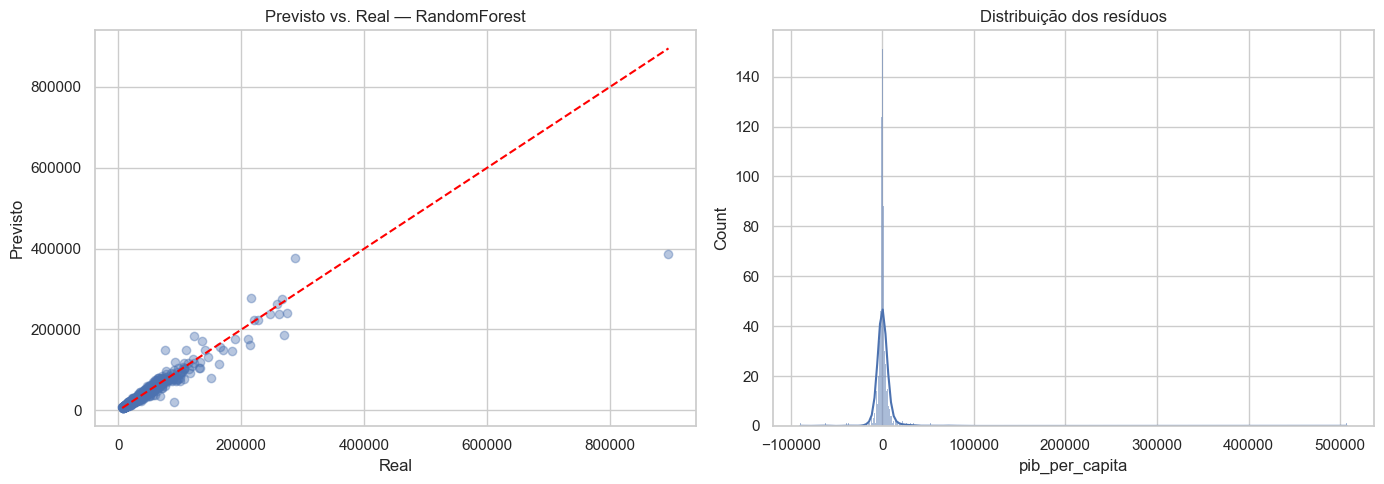

Melhor baseline: RandomForest


In [5]:
melhor_nome = df_resultados['RMSE'].idxmin()
melhor_pipe = pipelines[melhor_nome]
pred_melhor = melhor_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# pontos perto da linha vermelha (y=x) = boa previsão; espalhamento maior = mais erro
axes[0].scatter(y_test, pred_melhor, alpha=0.4)
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, color='red', linestyle='--')
axes[0].set_xlabel('Real')
axes[0].set_ylabel('Previsto')
axes[0].set_title(f'Previsto vs. Real — {melhor_nome}')

# resíduos centrados em 0 e simétricos = bom sinal; cauda longa = o modelo ainda erra mais nos outliers
residuos = y_test - pred_melhor
sns.histplot(residuos, kde=True, ax=axes[1])
axes[1].set_title('Distribuição dos resíduos')

plt.tight_layout()
plt.savefig('../reports/07_baseline_previsto_vs_real.png', dpi=120)
plt.show()

print(f'Melhor baseline: {melhor_nome}')


**Resultado:** o gráfico da esquerda mostra a grande maioria dos municípios bem colados na linha
vermelha (previsão = real) até a faixa de ~R$ 300 mil — mas tem um ponto isolado, bem longe da
linha, lá perto de R$ 900 mil de PIB per capita real. É o **Canaã dos Carajás-PA** (o mesmo outlier
de mineração da EDA e do notebook de SHAP): o RandomForest previu R$ 387.518 para um valor real de
R$ 894.763 — um erro de mais de R$ 500 mil num único município.

O histograma de resíduos mostra a mesma história de outro ângulo: um pico bem alto e estreito perto
de zero (a maioria dos municípios tem erro pequeno — 83% ficam com erro absoluto abaixo de
R$ 5 mil), e uma cauda longa e fina se estendendo até quase R$ 510 mil para a direita. Os resíduos
têm assimetria (skew) de **22,8** — um número gigante, bem maior até que a assimetria do próprio
alvo (7,9, visto na EDA). Isso confirma que o modelo herda — e até amplifica — a cauda longa da
distribuição do alvo: ele acerta bem o grosso dos municípios, mas erra muito nos poucos extremos.

**Por que isso importa:** é o mesmo padrão que reaparece no notebook 04 (gap entre RMSE de CV e de
teste) e no notebook 05 (Canaã dos Carajás como o caso de maior erro do SHAP) — não é coincidência,
é a mesma causa raiz se manifestando em três lugares diferentes: um alvo extremamente assimétrico
que nenhum dos modelos treinados até aqui consegue extrapolar bem para os casos mais extremos.

## 6. Salvar o baseline

In [6]:
# salva o pipeline inteiro (pré-processador + modelo), não só o modelo — assim a previsão em
# dados novos não exige reaplicar manualmente o StandardScaler/OneHotEncoder
joblib.dump(melhor_pipe, '../models/baseline_pipeline.joblib')
print(f'Pipeline salvo em ../models/baseline_pipeline.joblib ({melhor_nome})')


Pipeline salvo em ../models/baseline_pipeline.joblib (RandomForest)


## 7. Próximos passos
- Comparar mais modelos com validação cruzada (`03_Comparacao_Modelos_CV.ipynb`)
- Otimizar hiperparâmetros com Optuna (`04_Otimizacao_Optuna.ipynb`)